In [1]:
import os
import cv2
import math
import torch
import numpy as np
import supervision as sv

from collections import defaultdict
from ultralytics import YOLO
from tqdm import tqdm

In [2]:
if torch.cuda.is_available():
    device = 0
    print("GPU:", torch.cuda.get_device_name(0))
else:
    device = "cpu"
    print("Running on CPU")

GPU: NVIDIA GeForce GTX 1650


In [3]:
model = YOLO("yolo11n.pt")

print("YOLO11 Loaded")

YOLO11 Loaded


In [4]:
tracker = sv.ByteTrack()

print("ByteTrack Ready")

ByteTrack Ready


C:\Users\Acer\AppData\Local\Temp\ipykernel_6416\355437576.py:1: FutureWarning: The `ByteTrack` was deprecated since v0.28.0. It will be removed in v0.31.0.
  tracker = sv.ByteTrack()


In [5]:
video_path = "../videos/traffic.mp4"

if not os.path.exists(video_path):
    raise FileNotFoundError(video_path)

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise RuntimeError("Cannot open video")

print("Video Loaded")

Video Loaded


In [6]:
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fps = cap.get(cv2.CAP_PROP_FPS)

total_frames = int(
    cap.get(cv2.CAP_PROP_FRAME_COUNT)
)

print(f"Resolution : {width} x {height}")
print(f"FPS        : {fps:.2f}")
print(f"Frames     : {total_frames}")

Resolution : 1920 x 1080
FPS        : 30.00
Frames     : 1053


In [7]:
os.makedirs("../outputs", exist_ok=True)

output_path = "../outputs/traffic_analytics.mp4"

writer = cv2.VideoWriter(
    output_path,
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (width, height)
)

if not writer.isOpened():
    raise RuntimeError("Cannot create output video")

print("Output Writer Ready")

Output Writer Ready


In [8]:
VEHICLE_CLASSES = {

    1: "Bicycle",
    2: "Car",
    3: "Motorcycle",
    5: "Bus",
    7: "Truck"

}

print(VEHICLE_CLASSES)

{1: 'Bicycle', 2: 'Car', 3: 'Motorcycle', 5: 'Bus', 7: 'Truck'}


In [9]:
LINE_Y = height // 2

LINE_START = (0, LINE_Y)
LINE_END = (width, LINE_Y)

print("Counting Line:", LINE_Y)

Counting Line: 540


In [10]:
vehicle_counter = defaultdict(int)

counted_ids = set()

incoming = 0
outgoing = 0

total_count = 0

In [11]:
track_history = {}

print("Tracking history initialized")

Tracking history initialized


In [12]:
box_annotator = sv.BoxAnnotator()

label_annotator = sv.LabelAnnotator()

print("Annotators Ready")

Annotators Ready


In [28]:
from collections import defaultdict

# Reopen video from beginning
cap.release()

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise RuntimeError("Cannot open video")


# Reset tracker
tracker = sv.ByteTrack()


# Reset analytics
vehicle_counter = defaultdict(int)

counted_ids = set()

track_history = {}

total_count = 0
incoming = 0
outgoing = 0


# Frame counter
processed_frames = 0


print("Video restarted")
print(
    "Total frames:",
    int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
)

Video restarted
Total frames: 1053


In [29]:
os.makedirs("../outputs", exist_ok=True)

output_path = "../outputs/traffic_analytics.mp4"


writer = cv2.VideoWriter(
    output_path,
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (width, height)
)


if not writer.isOpened():
    raise RuntimeError("Writer failed")


print("Writer ready")

Writer ready


In [30]:
box_annotator = sv.BoxAnnotator()

label_annotator = sv.LabelAnnotator()

print("Annotators ready")

Annotators ready


In [31]:
for _ in tqdm(range(total_frames), desc="Processing"):

    success, frame = cap.read()

    if not success:
        break


    processed_frames += 1


    # -----------------------------
    # YOLO Detection
    # -----------------------------
    result = model.predict(
        frame,
        conf=0.35,
        device=device,
        verbose=False
    )[0]


    detections = sv.Detections.from_ultralytics(
        result
    )


    # -----------------------------
    # Vehicle Filtering
    # -----------------------------
    if len(detections) > 0:

        mask = [
            class_id in VEHICLE_CLASSES
            for class_id in detections.class_id
        ]

        detections = detections[mask]


    # -----------------------------
    # Tracking
    # -----------------------------
    detections = tracker.update_with_detections(
        detections
    )


    labels = []


    # -----------------------------
    # Counting Logic
    # -----------------------------
    if detections.tracker_id is not None:

        for box, class_id, track_id in zip(
            detections.xyxy,
            detections.class_id,
            detections.tracker_id
        ):

            x1, y1, x2, y2 = box


            center_y = int(
                (y1 + y2) / 2
            )


            if track_id in track_history:

                previous_y = track_history[track_id]


                # Moving downward
                if (
                    previous_y < LINE_Y
                    and center_y >= LINE_Y
                    and track_id not in counted_ids
                ):

                    counted_ids.add(track_id)

                    vehicle_counter[
                        VEHICLE_CLASSES[class_id]
                    ] += 1

                    total_count += 1

                    incoming += 1


                # Moving upward
                elif (
                    previous_y > LINE_Y
                    and center_y <= LINE_Y
                    and track_id not in counted_ids
                ):

                    counted_ids.add(track_id)

                    vehicle_counter[
                        VEHICLE_CLASSES[class_id]
                    ] += 1

                    total_count += 1

                    outgoing += 1


            track_history[track_id] = center_y


            labels.append(
                f"{VEHICLE_CLASSES[class_id]} ID:{track_id}"
            )


    # -----------------------------
    # Draw Boxes
    # -----------------------------
    annotated = box_annotator.annotate(
        scene=frame.copy(),
        detections=detections
    )


    annotated = label_annotator.annotate(
        scene=annotated,
        detections=detections,
        labels=labels
    )


    # -----------------------------
    # Draw Counting Line
    # -----------------------------
    cv2.line(
        annotated,
        LINE_START,
        LINE_END,
        (0,0,255),
        3
    )


    # -----------------------------
    # Dashboard
    # -----------------------------
    y = 35


    cv2.putText(
        annotated,
        f"Total: {total_count}",
        (20,y),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0,255,0),
        2
    )


    y += 35


    for vehicle, count in vehicle_counter.items():

        cv2.putText(
            annotated,
            f"{vehicle}: {count}",
            (20,y),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255,255,255),
            2
        )

        y += 30


    writer.write(annotated)


print("Processing finished")
print("Frames processed:", processed_frames)

Processing: 100%|██████████| 1053/1053 [01:17<00:00, 13.56it/s]

Processing finished
Frames processed: 1053


In [32]:
cap.release()

writer.release()


print("Saved:")
print(os.path.abspath(output_path))

Saved:
d:\Computer Vision Projects\5.Traffic Video Analysis\outputs\traffic_analytics.mp4


In [33]:
import os

print(
    "Video exists:",
    os.path.exists(output_path)
)


print(
    "Total vehicles:",
    total_count
)


print(
    "Vehicle counts:",
    dict(vehicle_counter)
)

Video exists: True
Total vehicles: 4
Vehicle counts: {'Truck': 3, 'Car': 1}


In [35]:
from collections import defaultdict
from IPython.display import display, clear_output
from PIL import Image

# Reopen video from beginning
cap.release()

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise RuntimeError("Cannot open video")


# Reset tracker
tracker = sv.ByteTrack()


# Reset analytics
vehicle_counter = defaultdict(int)

counted_ids = set()

track_history = {}

total_count = 0
incoming = 0
outgoing = 0


# Reset frame counter
processed_frames = 0


print("Video reset successfully")
print(
    "Frames:",
    int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
)

Video reset successfully
Frames: 1053


In [36]:
output_path = "../outputs/traffic_live_dashboard.mp4"


writer = cv2.VideoWriter(
    output_path,
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (width, height)
)


if not writer.isOpened():
    raise RuntimeError("Video writer failed")


print("Writer ready")

Writer ready


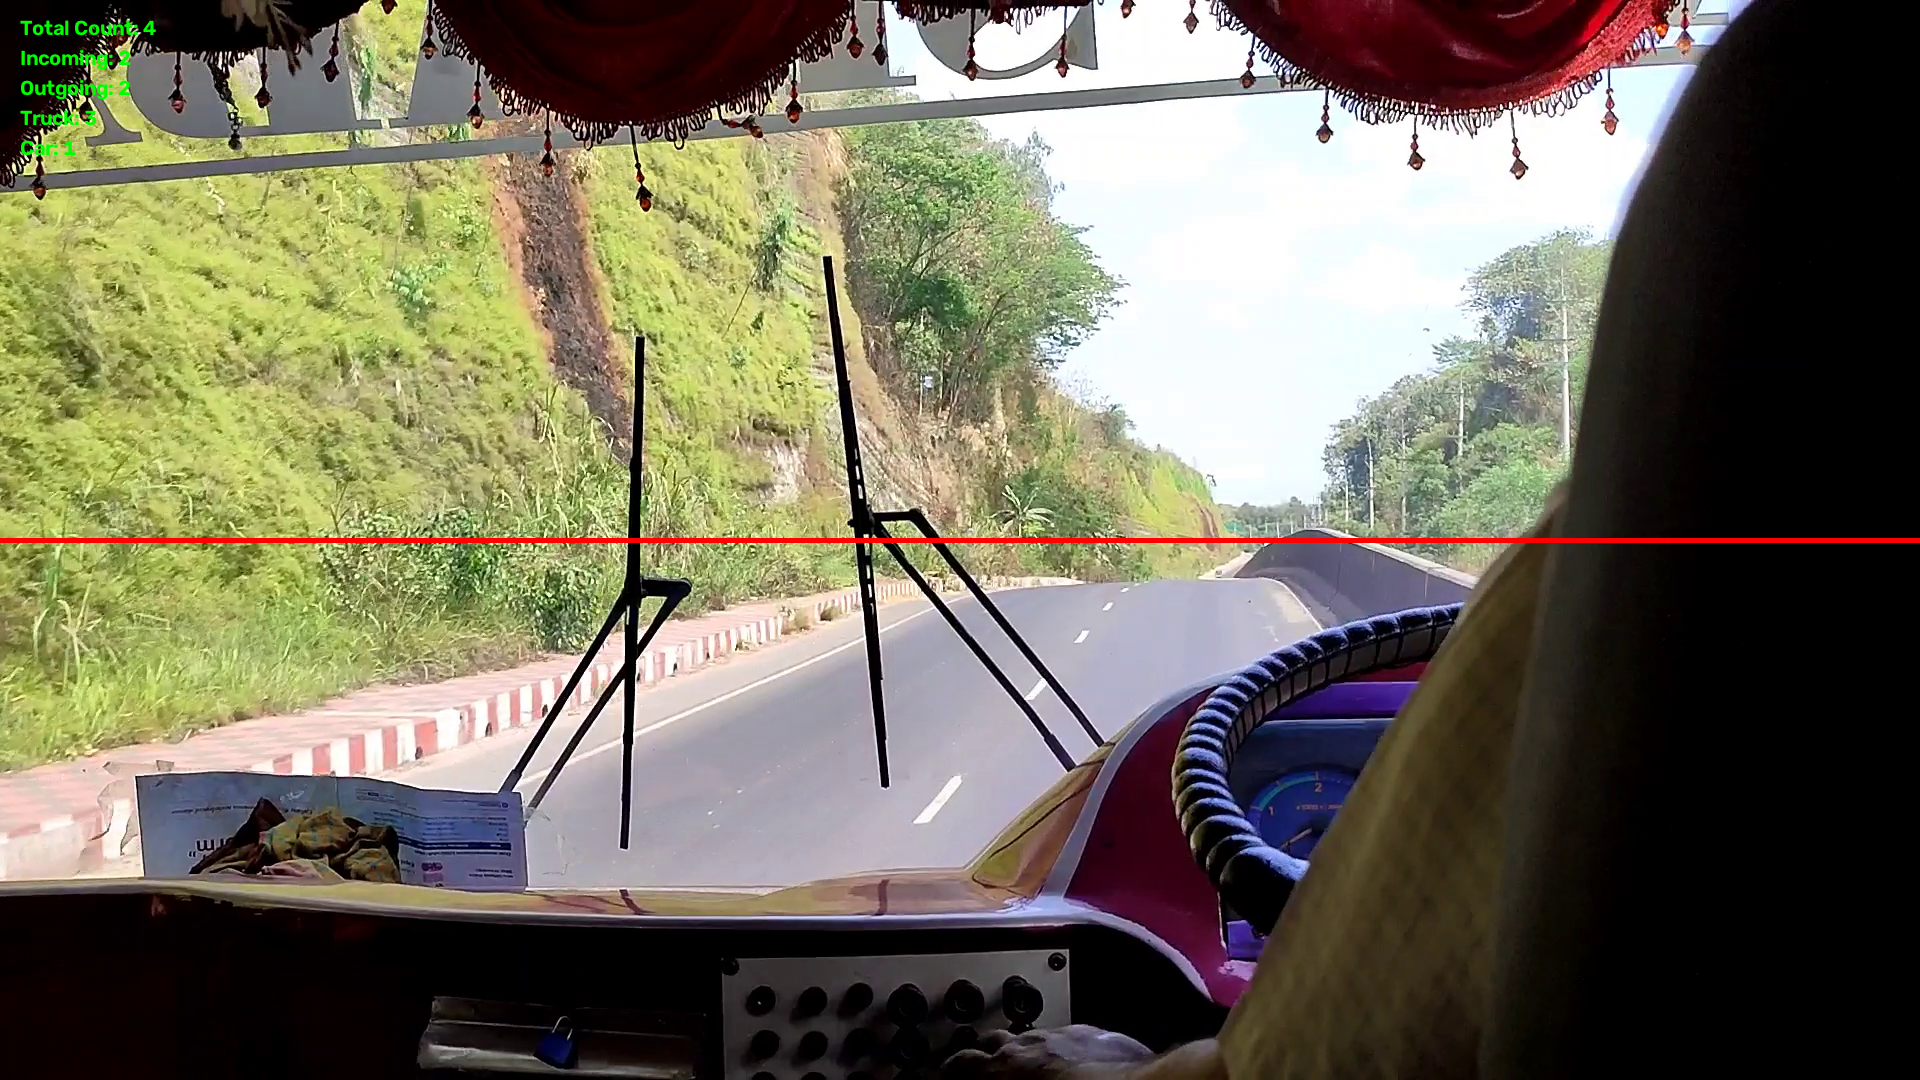

Processing: 100%|██████████| 1053/1053 [06:02<00:00,  2.90it/s]

Processing finished
Frames processed: 1053


In [37]:
for _ in tqdm(range(total_frames), desc="Processing"):

    success, frame = cap.read()

    if not success:
        break


    processed_frames += 1


    # YOLO Detection
    result = model.predict(
        frame,
        conf=0.35,
        device=device,
        verbose=False
    )[0]


    detections = sv.Detections.from_ultralytics(
        result
    )


    # Vehicle filtering
    if len(detections) > 0:

        mask = [
            class_id in VEHICLE_CLASSES
            for class_id in detections.class_id
        ]

        detections = detections[mask]


    # Tracking
    detections = tracker.update_with_detections(
        detections
    )


    labels = []


    # Counting logic
    if detections.tracker_id is not None:

        for box, class_id, track_id in zip(
            detections.xyxy,
            detections.class_id,
            detections.tracker_id
        ):

            x1, y1, x2, y2 = box


            center_y = int(
                (y1 + y2) / 2
            )


            if track_id in track_history:

                previous_y = track_history[track_id]


                if (
                    previous_y < LINE_Y
                    and center_y >= LINE_Y
                    and track_id not in counted_ids
                ):

                    counted_ids.add(track_id)

                    vehicle_counter[
                        VEHICLE_CLASSES[class_id]
                    ] += 1

                    total_count += 1
                    incoming += 1


                elif (
                    previous_y > LINE_Y
                    and center_y <= LINE_Y
                    and track_id not in counted_ids
                ):

                    counted_ids.add(track_id)

                    vehicle_counter[
                        VEHICLE_CLASSES[class_id]
                    ] += 1

                    total_count += 1
                    outgoing += 1


            track_history[track_id] = center_y


            labels.append(
                f"{VEHICLE_CLASSES[class_id]} ID:{track_id}"
            )


    # Draw boxes
    annotated = box_annotator.annotate(
        scene=frame.copy(),
        detections=detections
    )


    annotated = label_annotator.annotate(
        scene=annotated,
        detections=detections,
        labels=labels
    )


    # Counting line
    cv2.line(
        annotated,
        LINE_START,
        LINE_END,
        (0,0,255),
        3
    )


    # Dashboard
    y = 35


    dashboard = [
        f"Total Count: {total_count}",
        f"Incoming: {incoming}",
        f"Outgoing: {outgoing}"
    ]


    for vehicle, count in vehicle_counter.items():
        dashboard.append(
            f"{vehicle}: {count}"
        )


    for text in dashboard:

        cv2.putText(
            annotated,
            text,
            (20,y),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0,255,0),
            2
        )

        y += 30


    # Save video
    writer.write(annotated)


    # LIVE DISPLAY
    rgb = cv2.cvtColor(
        annotated,
        cv2.COLOR_BGR2RGB
    )

    clear_output(wait=True)

    display(
        Image.fromarray(rgb)
    )


print("Processing finished")
print("Frames processed:", processed_frames)

In [38]:
cap.release()
writer.release()


clear_output(wait=True)


print("Completed")
print(
    "Frames processed:",
    processed_frames
)

print(
    "Total vehicles:",
    total_count
)

print(
    "Vehicle breakdown:"
)

for k,v in vehicle_counter.items():
    print(k, ":", v)


print("\nSaved video:")
print(os.path.abspath(output_path))

Completed
Frames processed: 1053
Total vehicles: 4
Vehicle breakdown:
Truck : 3
Car : 1

Saved video:
d:\Computer Vision Projects\5.Traffic Video Analysis\outputs\traffic_live_dashboard.mp4
